# Wellbeing Panel — a multi-wave study

**The study.** A three-wave online panel on wellbeing (WHO-5) and working from home. The same respondents are invited every quarter through a panel provider that appends their id to the link. Wave 2 adds a question. The team needs one codebook for all waves, an archive of each wave with its metadata, a long file for trends, a wide file for within-person change, and files for colleagues in SPSS, Stata and R.

**What this notebook shows.** A codebook factory (`core_variables()`) so each wave extends a fresh registry; capturing an external id with an `onInit` script from the URL (stored with the response — verified in a headless browser); `role="id"` and `DUPLICATE_ID`; `deadline=` and `max_responses`; a real local deployment of wave 1; JSON dictionaries and the SPSS/Stata round trips with their limits; stacking waves with a `wave` variable; `Report.combine()`; the R bundle.

In [1]:
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

import siamang as sg
from siamang.core import ContentPage, FinalPage, Matrix, MissingValue, MultiChoice
from siamang.core.question import question_output_name
from siamang.io import DictionaryReader, DictionaryWriter, SPSSWriter, StataWriter, read_spss, read_stata

from siamang.reporting.tables import CrossTable, FreqTable, GroupMeanTable
for _cls in (FreqTable, CrossTable, GroupMeanTable):   # text/plain fallback = Markdown table; the HTML view is unchanged
    get_ipython().display_formatter.formatters["text/plain"].for_type(_cls, lambda t, p, cycle: p.text(t.to_markdown()))
OUT = Path("out"); OUT.mkdir(exist_ok=True)
print("siamang", sg.__version__)

siamang 0.6.0


## 1. The shared codebook

In [2]:
WHO5 = {0: "At no time", 1: "Some of the time", 2: "Less than half the time",
        3: "More than half the time", 4: "Most of the time", 5: "All of the time"}

panel_id = sg.Variable("panel_id", scale="nominal", label="Panel member ID", dtype="str", role="id")
age = sg.Variable("age", scale="ratio", label="Age (years)", dtype="int", valid_range=(18, 90))
gender = sg.Variable("gender", scale="nominal", label="Gender",
                     labels={1: "Woman", 2: "Man", 3: "Other", 99: "Prefer not to say"},
                     missing=(MissingValue(99, "Prefer not to say", kind="refusal"),))
employment = sg.Variable("employment", scale="nominal", label="Employment status",
                         labels={1: "Employed", 2: "Self-employed", 3: "Unemployed", 4: "Retired", 5: "Other"})
remote_days = sg.Variable("remote_days", scale="ratio", label="Days per week working from home",
                          dtype="int", valid_range=(0, 7))

def who5(name: str, label: str) -> sg.Variable:
    return sg.Variable(name, scale="ordinal", label=label, labels=WHO5,
                       construct="wellbeing_who5", source="WHO-5 Well-Being Index")

wb_cheerful = who5("wb_cheerful", "I have felt cheerful and in good spirits")
wb_calm = who5("wb_calm", "I have felt calm and relaxed")
wb_active = who5("wb_active", "I have felt active and vigorous")
wb_rested = who5("wb_rested", "I woke up feeling fresh and rested")
wb_interest = who5("wb_interest", "My daily life has been filled with things that interest me")
WB_ITEMS = [wb_cheerful, wb_calm, wb_active, wb_rested, wb_interest]
life_sat = sg.Variable("life_sat", scale="interval", label="Life satisfaction (0-10)",
                       dtype="int", valid_range=(0, 10))


def core_variables() -> sg.VariableMap:
    """A *fresh* registry each time, so each wave can add its own variables."""
    vm = sg.VariableMap()
    vm.add_many([panel_id, age, gender, employment, remote_days, *WB_ITEMS, life_sat])
    return vm

print(len(core_variables()), "core variables")

11 core variables


## 2. Two wave modules

`panel_id` stays registered but bound to no question — the strict lint level reports `UNUSED_VARIABLE` as a *warning*, so strict validation still passes. Both waves share the page builders; wave 2 adds `job_change`.

In [3]:
# The panel provider appends ?pid=<member id> to the survey link; an onInit script
# copies it into the answers so it is stored with every submission.
capture_pid = sg.Script(
    name="capture_panel_id", trigger="onInit",
    code="answers.panel_id = new URLSearchParams(window.location.search).get('pid') || 'unknown';",
)


def about_page(extra=()):
    return sg.Page("about", title="About you", items=[
        sg.NumericInput("How old are you?", var=age, required=True, unit="years"),
        sg.SingleChoice("Which best describes you?", var=gender),
        sg.SingleChoice("What is your current employment status?", var=employment, required=True),
        *extra,
        sg.NumericInput("How many days a week do you work from home?", var=remote_days,
                        display="slider", show_if=employment.isin([1, 2])),
    ])


def wellbeing_page():
    return sg.Page("wellbeing", title="Over the last two weeks…", items=[
        sg.Matrix("Please indicate for each statement which is closest to how you have been feeling.",
                  var=WB_ITEMS),
        sg.NumericInput("All things considered, how satisfied are you with your life as a whole?",
                        var=life_sat, display="slider", step=1,
                        hint="0 = extremely dissatisfied, 10 = extremely satisfied"),
    ])


# ── Wave 1: the core codebook as-is ──────────────────────────────────────────
wave1 = sg.Questionnaire(
    title="Wellbeing Panel — Wave 1", variables=core_variables(), scripts=[capture_pid],
    deadline=datetime(2026, 10, 31, 23, 59, tzinfo=timezone.utc),
    pages=[ContentPage("intro", title="Welcome back", body="<p>Wave 1 of 3. About 5 minutes.</p>"),
           about_page(), wellbeing_page(),
           FinalPage("thanks", title="Thank you", body="<p>See you next quarter.</p>")],
)

# ── Wave 2: one wave-specific addition on top of the shared codebook ─────────
job_change = sg.Variable("job_change", scale="nominal", label="Changed job since the last wave",
                         labels={1: "Yes", 2: "No"})
vars_w2 = core_variables(); vars_w2.add(job_change)
wave2 = sg.Questionnaire(
    title="Wellbeing Panel — Wave 2", variables=vars_w2, scripts=[capture_pid],
    deadline=datetime(2027, 1, 31, 23, 59, tzinfo=timezone.utc),
    pages=[ContentPage("intro", title="Welcome back", body="<p>Wave 2 of 3. About 5 minutes.</p>"),
           about_page(extra=[sg.SingleChoice("Have you changed jobs since the last survey?",
                                             var=job_change, show_if=employment.isin([1, 2]))]),
           wellbeing_page(),
           FinalPage("thanks", title="Thank you", body="<p>One more wave to go.</p>")],
)
options = {"max_responses": 2000}

for w in (wave1, wave2):
    w.validate(strict=True)
    print(w.title, "→ strict lint:", [f"{x.code}({x.location})" for x in w.lint(level="strict")])

Wellbeing Panel — Wave 1 → strict lint: ['UNUSED_VARIABLE(panel_id)']
Wellbeing Panel — Wave 2 → strict lint: ['UNUSED_VARIABLE(panel_id)']


## 3. What the browser stores: local deployment of wave 1

The script reads `?pid=` from the URL, so a browser submission carries `panel_id`. Here we post the same payload the runtime would (verified with Playwright in the cookbook), collect it, and flatten the Matrix dict into per-item columns.

In [4]:
def flatten_responses(frame: pd.DataFrame, survey: sg.Questionnaire) -> pd.DataFrame:
    frame = frame.loc[:, ~frame.columns.str.startswith("__")].copy()
    for q in survey.all_questions():
        qid = question_output_name(q)
        if isinstance(q, Matrix) and qid in frame.columns:
            cells = frame.pop(qid)
            for v in q.var:
                frame[v.name] = cells.map(lambda d, n=v.name: d.get(n) if isinstance(d, dict) else np.nan)
        elif isinstance(q, MultiChoice) and q.mode == "wide" and qid in frame.columns:
            picks = frame.pop(qid)
            for v in q.var:
                frame[v.name] = picks.map(lambda s, n=v.name: int(n in s) if isinstance(s, list) else np.nan)
    return frame


result = wave1.deploy(backend_kwargs={"path": str(OUT / "wave1.db")}, frontend_kwargs={"host": "127.0.0.1"}, **options)
payload = {"panel_id": "P0042", "age": 41, "gender": 1, "employment": 3,
           "matrix_wb_cheerful": {"wb_cheerful": 3, "wb_calm": 3, "wb_active": 2, "wb_rested": 4, "wb_interest": 3},
           "life_sat": 7, "__options__": {}, "__pages__": [], "__errors__": {}}
print(requests.post(f"{result.url}/responses", json={"survey_id": result.survey_id, "responses": payload}, timeout=5).json())
raw = result.collect()
result.frontend_ref.stop()
flat = flatten_responses(raw, wave1)
print("stored columns:", list(raw.columns))
flat

{'ok': True, 'response_id': 1}
stored columns: ['panel_id', 'age', 'gender', 'employment', 'matrix_wb_cheerful', 'life_sat', '__options__', '__pages__', '__errors__', '_response_id', '_submitted_at']


,panel_id,age,gender,employment,life_sat,_response_id,_submitted_at,wb_cheerful,wb_calm,wb_active,wb_rested,wb_interest
0,P0042,41,1,3,7,1,2026-09-03 01:59:16,3,3,2,4,3


## 4. Two waves of rehearsal data

`simulate()` runs no scripts, so panel ids are attached in pandas; wave 2 keeps 75% of wave-1 members. Each wave is validated against its own codebook — `role="id"` makes `validate()` catch duplicated ids.

In [5]:
wb_cols = [v.name for v in WB_ITEMS]

def prepare(data: sg.SurveyData, ids: pd.Series, wave: int) -> sg.SurveyData:
    data = data.with_frame(data.frame.assign(panel_id=ids.values, wave=wave))
    data.variables.add(sg.Variable("wave", scale="ordinal", label="Wave", labels={1: "Wave 1", 2: "Wave 2"}))
    data = data.apply_missing_values()                                   # gender 99 → NA
    data = data.with_frame(data.frame.assign(gender=pd.to_numeric(data.frame["gender"])))
    return data.create_index("who5", items=wb_cols, method="sum", label="WHO-5 score (0-25)")

w1 = prepare(wave1.simulate(n=400, seed=1), pd.Series([f"P{i:04d}" for i in range(1, 401)]), wave=1)
rng = np.random.default_rng(3)
w2 = prepare(wave2.simulate(n=300, seed=2), pd.Series(rng.choice(w1.frame["panel_id"], size=300, replace=False)), wave=2)

for name, d in (("wave 1", w1), ("wave 2", w2)):
    print(name, "errors:", [i.code for i in d.validate() if i.severity == "error"] or "none")
dup = w1.with_frame(pd.concat([w1.frame, w1.frame.iloc[[0]]], ignore_index=True))
print("with a duplicated id →", [i.code for i in dup.validate() if i.severity == "error"])
w1.describe_variables()

wave 1 errors: none
wave 2 errors: none
with a duplicated id → ['DUPLICATE_ID']


,name,label,scale,n,n_missing,n_unique
0,panel_id,Panel member ID,nominal,400,0,400
1,age,Age (years),ratio,400,0,72
2,gender,Gender,nominal,400,103,3
3,employment,Employment status,nominal,400,0,5
4,remote_days,Days per week working from home,ratio,400,240,8
5,wb_cheerful,I have felt cheerful and in good spirits,ordinal,400,0,6
6,wb_calm,I have felt calm and relaxed,ordinal,400,0,6
7,wb_active,I have felt active and vigorous,ordinal,400,0,6
8,wb_rested,I woke up feeling fresh and rested,ordinal,400,0,6
9,wb_interest,My daily life has been filled with things that...,ordinal,400,0,6


## 5. Archive a wave and prove the round trips

- **JSON dictionary**: everything in the `VariableMap`, including missing *kinds*, roles, constructs and sources — ship it with every CSV/Excel export.
- **SPSS `.sav`**: variable labels, value labels, missing codes and measurement levels — but SPSS has only nominal / ordinal / scale, so `ratio` variables come back as `interval`; `dtype`, `valid_range` and missing *kinds* are lost (see the `codebook()` below).
- **Stata `.dta`**: labels, but only single-letter extended missing values, so numeric codes such as 99 return as ordinary labelled values; measurement levels are not stored.

In [6]:
DictionaryWriter().write(w1.variables, OUT / "panel_dictionary.json")
w1.export("csv", path=str(OUT / "wave1.csv"))
restored = sg.SurveyData(frame=pd.read_csv(OUT / "wave1.csv"),
                         variables=DictionaryReader().read(OUT / "panel_dictionary.json"))
assert restored.variables["gender"].labels == w1.variables["gender"].labels
print("dictionary keeps missing kinds:", restored.variables["gender"].missing_kinds_dict())

SPSSWriter().write(w1, OUT / "wave1.sav")
back = read_spss(str(OUT / "wave1.sav"))
print("SPSS keeps:", back.variables["wb_calm"].labels[5], "|", back.variables["life_sat"].scale,
      "| missing codes:", back.variables["gender"].missing_values)

StataWriter().write(w1, OUT / "wave1.dta", version=15)
back_dta = read_stata(str(OUT / "wave1.dta"))
print("Stata keeps labels:", back_dta.variables["wb_calm"].labels.get(5),
      "| numeric missing codes dropped:", back_dta.variables["gender"].missing_values)
back.codebook().head(8)          # note: age/remote_days come back as "interval", dtype is None

dictionary keeps missing kinds: {99: 'refusal'}
SPSS keeps: All of the time | interval | missing codes: (99.0,)
Stata keeps labels: All of the time | numeric missing codes dropped: ()


,name,label,scale,dtype,role,description,missing_values,missing_kinds,missing,valid_range
0,age,Age (years),interval,None,None,None,[],{},[],None
1,gender,Gender,nominal,None,None,None,[99.0],{99.0: 'system_missing'},"[{'code': 99.0, 'label': 'Prefer not to say', ...",None
2,employment,Employment status,nominal,None,None,None,[],{},[],None
3,remote_days,Days per week working from home,interval,None,None,None,[],{},[],None
4,wb_cheerful,I have felt cheerful and in good spirits,ordinal,None,None,None,[],{},[],None
5,wb_calm,I have felt calm and relaxed,ordinal,None,None,None,[],{},[],None
6,wb_active,I have felt active and vigorous,ordinal,None,None,None,[],{},[],None
7,wb_rested,I woke up feeling fresh and rested,ordinal,None,None,None,[],{},[],None


## 6. Long file: trends across waves

The wave-2 codebook is a superset, so it describes the stacked file. `data.report.means()` runs a t-test for the interval-scaled WHO-5 score with two waves.

In [7]:
panel = sg.SurveyData(frame=pd.concat([w1.frame, w2.frame], ignore_index=True), variables=w2.variables)
panel.report.crosstab("wave", "employment", pct="row")

Wave,Employed,Self-employed,Unemployed,Retired,Other,Total
Wave 1,21.5,18.5,19.5,17.0,23.5,400
Wave 2,18.3,18.3,24.0,22.0,17.3,300
Total,141.0,129.0,150.0,134.0,146.0,700


In [8]:
panel.report.means("who5", by="wave")

Wave,Mean,SD,Median,N
Wave 1,12.46,3.975,12.0,400
Wave 2,12.58,3.936,12.0,300


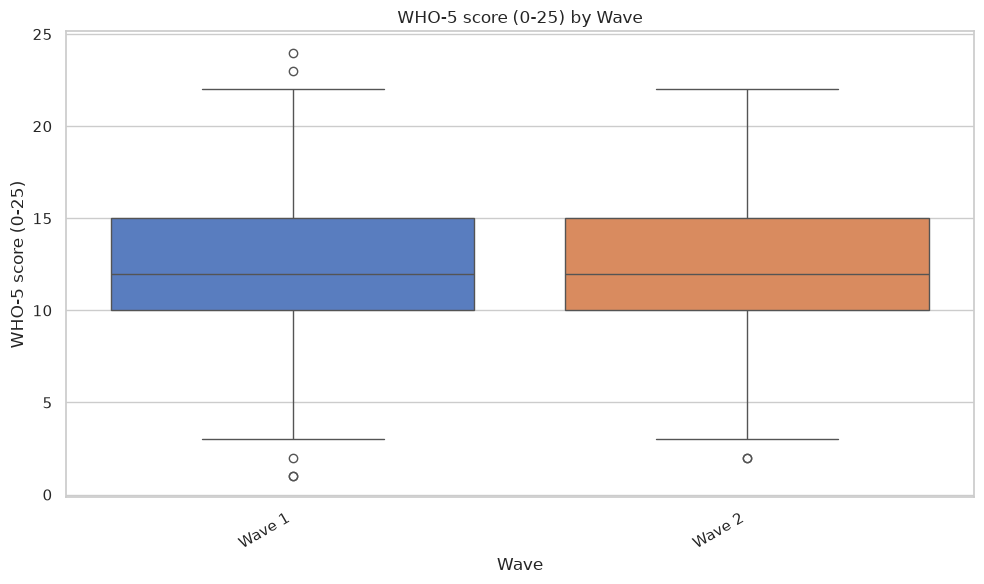

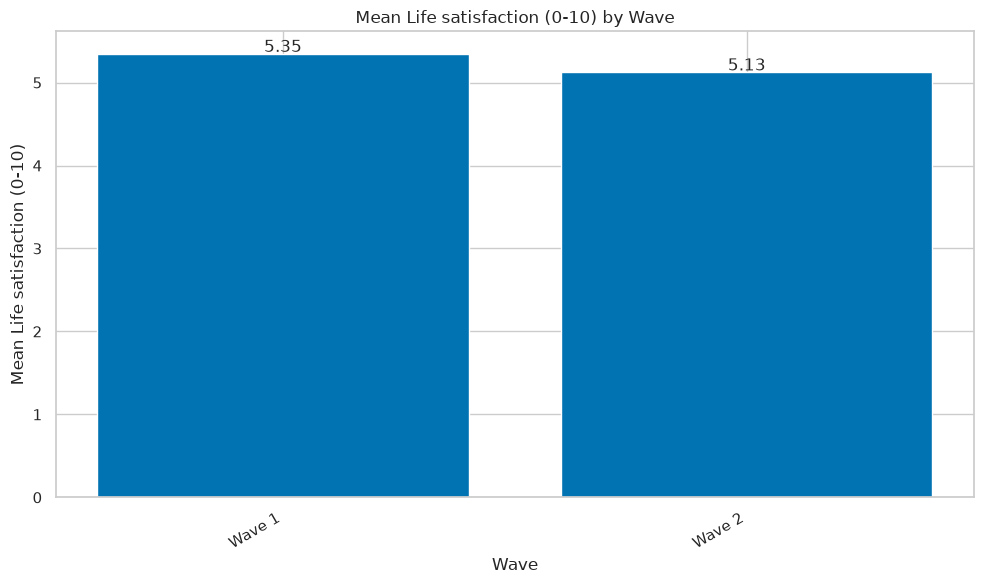

In [9]:
panel.plot.boxplot("who5", by="wave").plot(); plt.show()
panel.plot.bar("life_sat", by="wave", palette="colorblind").plot(); plt.show()

## 7. Wide file: within-person change

When the unit of analysis changes, build a *new* `SurveyData` whose small registry describes only the derived columns.

In [10]:
wide = (w1.frame.set_index("panel_id")[["who5", "life_sat", "employment"]]
        .join(w2.frame.set_index("panel_id")[["who5", "life_sat", "job_change"]],
              lsuffix="_w1", rsuffix="_w2", how="inner"))
wide["who5_change"] = wide["who5_w2"] - wide["who5_w1"]
print(f"panel cases: {len(wide)}, mean WHO-5 change: {wide['who5_change'].mean():+.2f}")

change = sg.SurveyData(frame=wide.reset_index(), variables=sg.VariableMap())
change.variables.add_many([
    sg.Variable("who5_change", scale="interval", label="Change in WHO-5 (w2 - w1)"),
    sg.Variable("job_change", scale="nominal", label="Changed job", labels={1: "Yes", 2: "No"}),
])
change.report.means("who5_change", by="job_change")

panel cases: 300, mean WHO-5 change: +0.15


Changed job,Mean,SD,Median,N
Yes,-0.839,6.014,0.0,56
No,1.537,4.709,1.0,54


## 8. Report per wave, combined, and the R bundle

In [11]:
def wave_report(d: sg.SurveyData, title: str) -> sg.Report:
    return (sg.Report(title=title)
            .value("Respondents", len(d.frame))
            .add(d.report.freq("employment"), caption="Employment status")
            .add(d.report.means("who5", by="employment"), caption="WHO-5 by employment"))

trend = (sg.Report(title="Trend", description="Wave 1 → Wave 2")
         .add(panel.report.means("who5", by="wave"), caption="WHO-5 score by wave")
         .add(panel.plot.boxplot("who5", by="wave"), caption="Figure 1. WHO-5 by wave")
         .add(change.report.means("who5_change", by="job_change"), caption="Within-person change by job change"))
full = sg.Report.combine([wave_report(w1, "Wave 1"), wave_report(w2, "Wave 2"), trend],
                         title="Wellbeing Panel — waves 1-2")
full.save(OUT / "panel_report.md")
plt.close("all")
panel.export("r", path=str(OUT / "panel_R"))
print(full.to_markdown(asset_dir=OUT)[:700])
print(sorted(p.name for p in OUT.iterdir()), sorted(p.name for p in (OUT / "panel_R").iterdir()))

# Wellbeing Panel — waves 1-2

## Contents
- [Wave 1](#wave-1)
- [Wave 2](#wave-2)
- [Trend](#trend)

## Wave 1

**Respondents:** 400

*Employment status*

| Value | Label | N | % | Cumulative % |
|---|---|---|---|---|
| 1 | Employed | 86 | 21.5 | 21.5 |
| 2 | Self-employed | 74 | 18.5 | 40.0 |
| 3 | Unemployed | 78 | 19.5 | 59.5 |
| 4 | Retired | 68 | 17.0 | 76.5 |
| 5 | Other | 94 | 23.5 | 100.0 |
|  | Total | 400 | 100.0 | 100.0 |

Variable = Employment status; N valid = 400

*WHO-5 by employment*

| Employment status | Mean | SD | Median | N |
|---|---|---|---|---|
| Employed | 12.291 | 4.459 | 13.0 | 86 |
| Self-employed | 11.73 | 3.299 | 12.0 | 74 |
| Unemployed | 12.833 | 3.939 | 13.0
['fig_12.png', 'panel_R', 'panel_dictionary.json', 'panel_report.md', 'wave1.csv', 'wave1.db', 'wave1.dta', 'wave1.sav'] ['import_survey.R', 'import_survey.csv', 'import_survey_dictionary.json']
